# Feature Importance Analysis

Understanding which features drive drug response predictions:
- LightGBM feature importance (gain-based)
- Top expression PCs (principal components)
- Tissue category contributions
- Drug-related features
- Feature interaction analysis

## 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import json
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_parquet("../data/processed/merged.parquet")
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {len([c for c in df.columns if c.startswith('PC')])}")

# Load best LightGBM parameters
with open("../results/baseline_lgbm/best_params.json", 'r') as f:
    best_params = json.load(f)
    
print(f"\nBest LightGBM parameters loaded:")
print(json.dumps(best_params, indent=2))

Dataset shape: (562789, 519)
Number of features: 512

Best LightGBM parameters loaded:
{
  "lr": 0.0120293225,
  "num_leaves": 225.0,
  "min_data_in_leaf": 230.0,
  "feature_fraction": 0.6301768205,
  "bagging_fraction": 0.6973485866,
  "bagging_freq": 3.0,
  "lambda_l1": 1.3848221053,
  "lambda_l2": 0.4870691276
}


## 2. Prepare Features and Train LightGBM

Train LightGBM model to extract feature importance.

In [2]:
# Extract features
pc_cols = [c for c in df.columns if c.startswith('PC')]
X = df[pc_cols].values
y = df['ln_ic50'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Add tissue one-hot if available
tissue_features = []
if 'tissue' in df.columns:
    from sklearn.preprocessing import OneHotEncoder
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    tissue_ohe = ohe.fit_transform(df[['tissue']].fillna('unknown'))
    tissue_feature_names = [f'tissue_{cat}' for cat in ohe.categories_[0]]
    tissue_features = tissue_feature_names
    X = np.concatenate([X, tissue_ohe], axis=1)
    print(f"Added {len(tissue_features)} tissue features")
    print(f"New feature matrix shape: {X.shape}")

feature_names = pc_cols + tissue_features

# Train LightGBM with best parameters
# Convert float parameters to int where needed
int_params = ['num_leaves', 'max_depth', 'min_data_in_leaf', 'max_bin', 'bagging_freq']
best_params_converted = {}
for k, v in best_params.items():
    if k in int_params and isinstance(v, float):
        best_params_converted[k] = int(v)
    else:
        best_params_converted[k] = v

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'seed': 42,
    **best_params_converted
}

# Create dataset
dtrain = lgb.Dataset(X, label=y, feature_name=feature_names)

# Train model
print("\nTraining LightGBM...")
model = lgb.train(lgb_params, dtrain, num_boost_round=500)
print("✓ Model trained successfully!")

Feature matrix shape: (562789, 512)
Target shape: (562789,)
Added 57 tissue features
New feature matrix shape: (562789, 569)

Training LightGBM...
✓ Model trained successfully!


## 3. Extract and Visualize Feature Importance

Analyze which features contribute most to predictions.

TOP 30 MOST IMPORTANT FEATURES


,feature,importance_gain,importance_split,importance_gain_pct
0,PC1,150518.232093,4565,8.285823
2,PC3,70416.780216,2548,3.876348
3,PC4,42231.317088,2293,2.324776
9,PC10,40354.187594,1073,2.221443
13,PC14,31733.367948,755,1.746879
1,PC2,27769.885947,3395,1.528694
11,PC12,21845.286161,856,1.202553
4,PC5,15258.984946,2043,0.839986
12,PC13,15001.738662,836,0.825825
16,PC17,13916.912429,646,0.766107


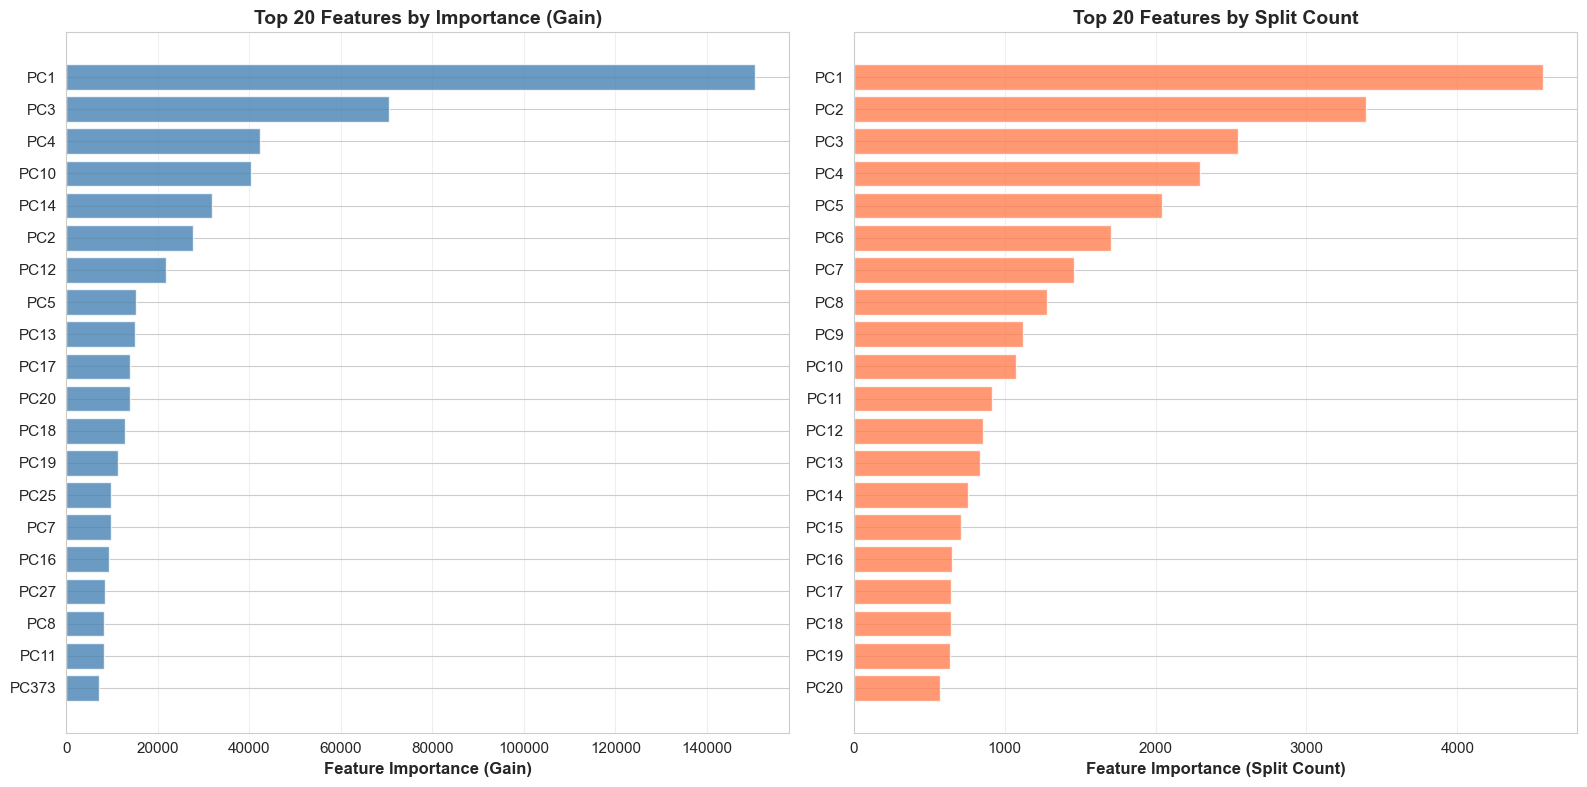

In [6]:
# Get feature importance (gain-based)
importance_gain = model.feature_importance(importance_type='gain')
importance_split = model.feature_importance(importance_type='split')

# Create DataFrame
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance_gain': importance_gain,
    'importance_split': importance_split
})

# Normalize to percentage
df_importance['importance_gain_pct'] = (df_importance['importance_gain'] / 
                                        df_importance['importance_gain'].sum() * 100)

# Sort by gain
df_importance = df_importance.sort_values('importance_gain', ascending=False)

# Display top 30
print("=" * 80)
print("TOP 30 MOST IMPORTANT FEATURES")
print("=" * 80)
display(df_importance.head(30))

# Plot top 20
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 by gain
top20 = df_importance.head(20)
axes[0].barh(range(len(top20)), top20['importance_gain'], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'])
axes[0].set_xlabel('Feature Importance (Gain)', fontweight='bold', fontsize=12)
axes[0].set_title('Top 20 Features by Importance (Gain)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top 20 by split count
top20_split = df_importance.nlargest(20, 'importance_split')
axes[1].barh(range(len(top20_split)), top20_split['importance_split'], color='coral', alpha=0.8)
axes[1].set_yticks(range(len(top20_split)))
axes[1].set_yticklabels(top20_split['feature'])
axes[1].set_xlabel('Feature Importance (Split Count)', fontweight='bold', fontsize=12)
axes[1].set_title('Top 20 Features by Split Count', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Expression PC Analysis

Analyze which principal components (gene expression patterns) are most important.

Total PCs analyzed: 512

Top 10 most important PCs:
feature  importance_gain_pct  pc_num
    PC1             8.285823       1
    PC3             3.876348       3
    PC4             2.324776       4
   PC10             2.221443      10
   PC14             1.746879      14
    PC2             1.528694       2
   PC12             1.202553      12
    PC5             0.839986       5
   PC13             0.825825      13
   PC17             0.766107      17


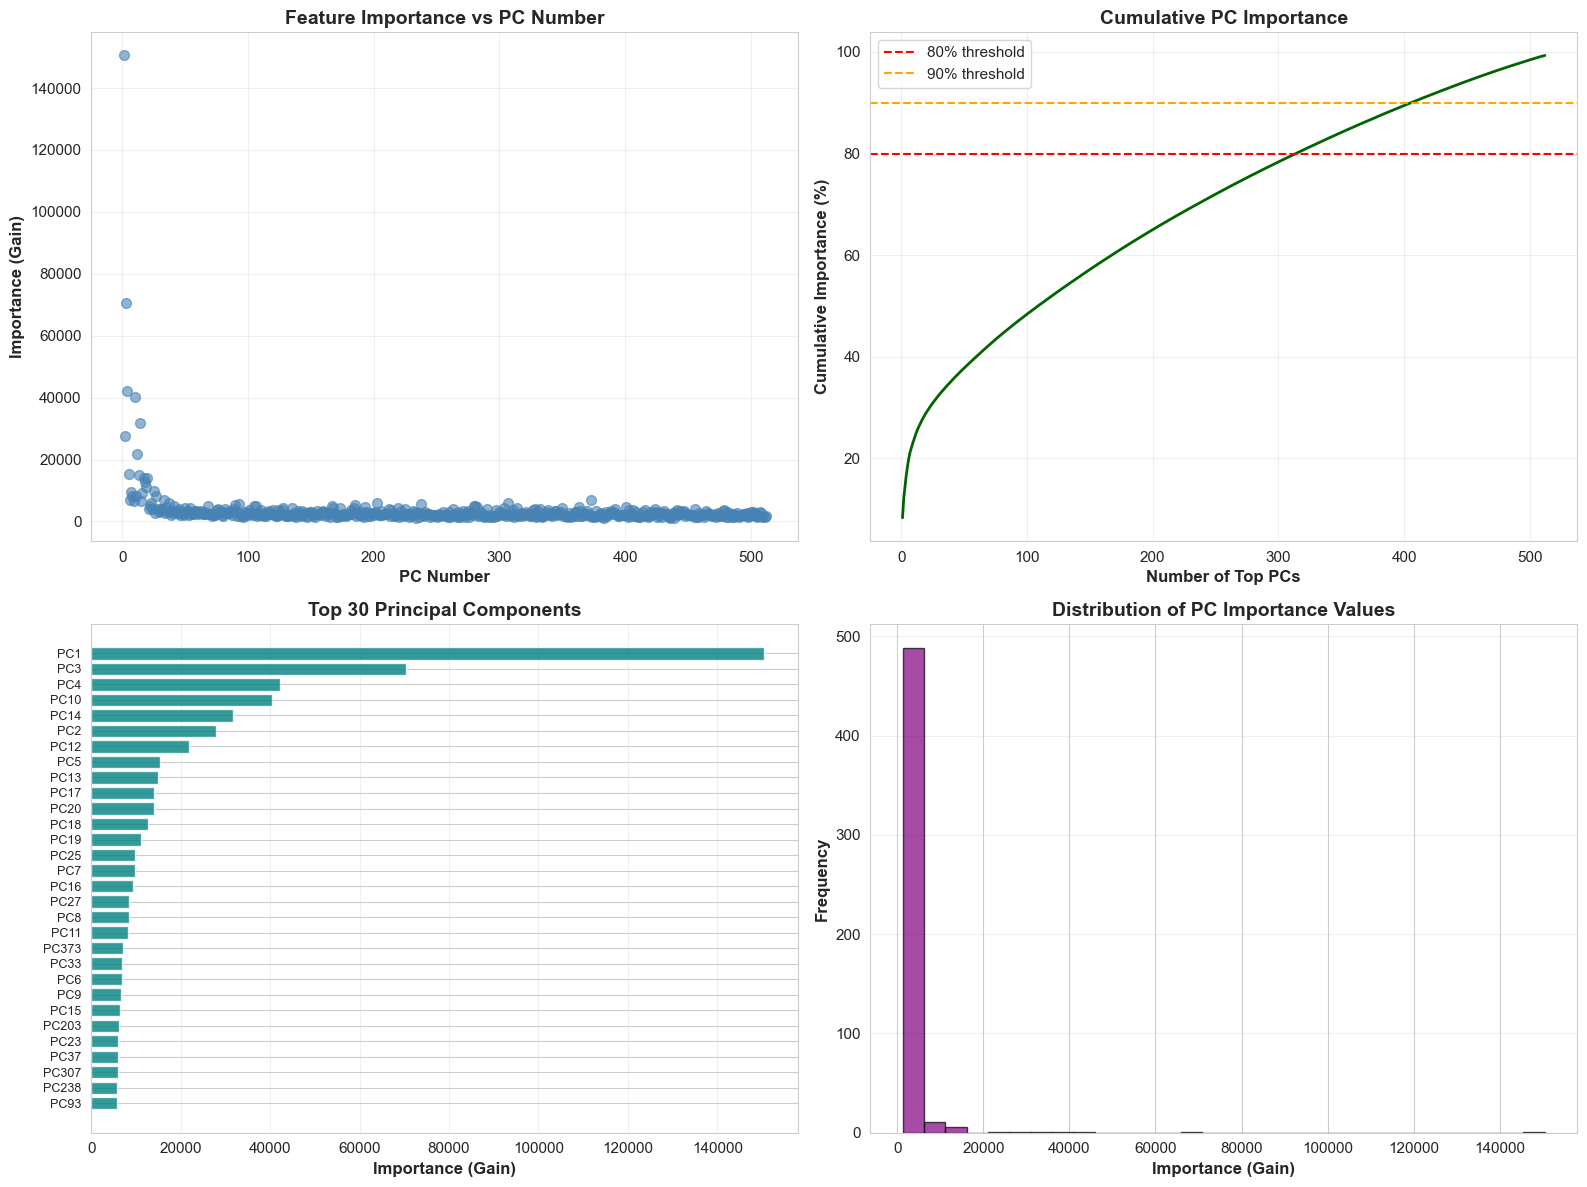


💡 Key Insights:
   • 292 PCs capture 80% of importance
   • 298 PCs capture 90% of importance
   • Top PC: PC1 (8.29%)


In [7]:
# Filter PC features
df_pc_importance = df_importance[df_importance['feature'].str.startswith('PC')].copy()

# Extract PC number
df_pc_importance['pc_num'] = df_pc_importance['feature'].str.extract('(\d+)').astype(int)
df_pc_importance = df_pc_importance.sort_values('pc_num')

print(f"Total PCs analyzed: {len(df_pc_importance)}")
print(f"\nTop 10 most important PCs:")
print(df_pc_importance.nlargest(10, 'importance_gain')[['feature', 'importance_gain_pct', 'pc_num']].to_string(index=False))

# Visualize PC importance distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Importance vs PC number
axes[0, 0].scatter(df_pc_importance['pc_num'], df_pc_importance['importance_gain'], 
                   alpha=0.6, s=50, color='steelblue')
axes[0, 0].set_xlabel('PC Number', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Importance (Gain)', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Feature Importance vs PC Number', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Cumulative importance
sorted_pcs = df_pc_importance.sort_values('importance_gain', ascending=False)
cumsum = sorted_pcs['importance_gain_pct'].cumsum()
axes[0, 1].plot(range(1, len(cumsum) + 1), cumsum, linewidth=2, color='darkgreen')
axes[0, 1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[0, 1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
axes[0, 1].set_xlabel('Number of Top PCs', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Cumulative Importance (%)', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Cumulative PC Importance', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Top 30 PCs bar chart
top_pcs = df_pc_importance.nlargest(30, 'importance_gain')
axes[1, 0].barh(range(len(top_pcs)), top_pcs['importance_gain'], color='teal', alpha=0.8)
axes[1, 0].set_yticks(range(len(top_pcs)))
axes[1, 0].set_yticklabels(top_pcs['feature'], fontsize=9)
axes[1, 0].set_xlabel('Importance (Gain)', fontweight='bold', fontsize=12)
axes[1, 0].set_title('Top 30 Principal Components', fontsize=14, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Importance distribution histogram
axes[1, 1].hist(df_pc_importance['importance_gain'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Importance (Gain)', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[1, 1].set_title('Distribution of PC Importance Values', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Find how many PCs needed for 80% and 90% importance
pcs_80 = (cumsum >= 80).idxmax() + 1
pcs_90 = (cumsum >= 90).idxmax() + 1
print(f"\n💡 Key Insights:")
print(f"   • {pcs_80} PCs capture 80% of importance")
print(f"   • {pcs_90} PCs capture 90% of importance")
print(f"   • Top PC: {sorted_pcs.iloc[0]['feature']} ({sorted_pcs.iloc[0]['importance_gain_pct']:.2f}%)")

## 5. Tissue Feature Analysis

Analyze which tissue types are most important for predictions (if available).

Total tissue categories: 57

Tissue feature importance:
                               tissue_clean  importance_gain_pct
          leukemia / lymphoblastic_leukemia             0.337357
                                   pancreas             0.131310
                 lymphoma / B_cell_lymphoma             0.125567
                        lung / mesothelioma             0.040873
                      bone / ewings_sarcoma             0.008355
         leukemia / acute_myeloid_leukaemia             0.008134
                                    myeloma             0.008044
                   soft_tissue / soft_other             0.005358
                  urogenital_system / ovary             0.003825
         lymphoma / lymphoid_neoplasm other             0.003785
                 leukemia / T_cell_leukemia             0.003440
                 digestive_system / stomach             0.002203
                 leukemia / B_cell_leukemia             0.001744
urogenital_system / urogenital_sys

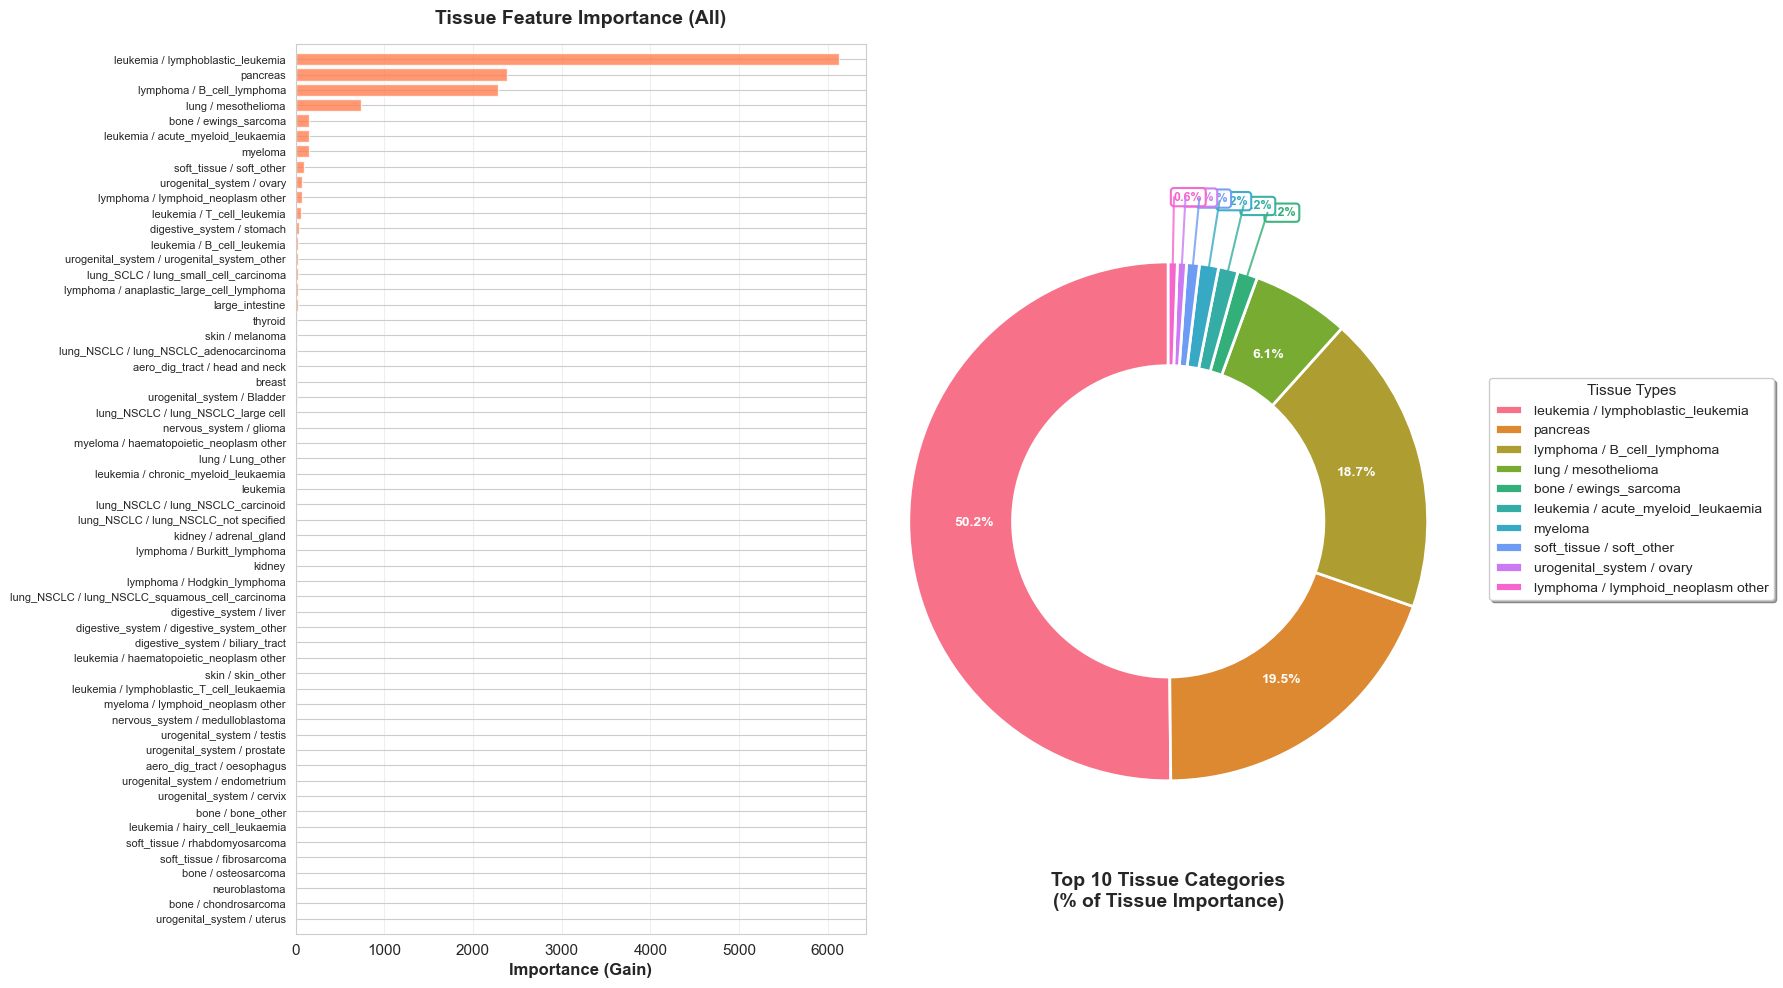


📊 Feature Category Comparison:
   • Total PC importance: 1804006.42
   • Total Tissue importance: 12569.00
   • PC contribution: 99.3%
   • Tissue contribution: 0.7%


In [13]:
if len(tissue_features) > 0:
    # Filter tissue features
    df_tissue_importance = df_importance[df_importance['feature'].str.startswith('tissue_')].copy()
    
    # Clean tissue names
    df_tissue_importance['tissue_clean'] = df_tissue_importance['feature'].str.replace('tissue_', '')
    df_tissue_importance = df_tissue_importance.sort_values('importance_gain', ascending=False)
    
    print(f"Total tissue categories: {len(df_tissue_importance)}")
    print(f"\nTissue feature importance:")
    print(df_tissue_importance[['tissue_clean', 'importance_gain_pct']].head(15).to_string(index=False))
    
    # Calculate figure height based on number of tissues (0.18 inch per tissue for compact view)
    n_tissues = len(df_tissue_importance)
    fig_height = max(6, n_tissues * 0.18)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(18, fig_height))
    
    # All tissues - with clean spacing
    axes[0].barh(range(len(df_tissue_importance)), df_tissue_importance['importance_gain'], 
                 color='coral', alpha=0.8, height=0.8)
    axes[0].set_yticks(range(len(df_tissue_importance)))
    axes[0].set_yticklabels(df_tissue_importance['tissue_clean'], fontsize=8)
    axes[0].set_xlabel('Importance (Gain)', fontweight='bold', fontsize=12)
    axes[0].set_title('Tissue Feature Importance (All)', fontsize=14, fontweight='bold', pad=15)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)
    # Add extra margin for long tissue names
    axes[0].margins(y=0.01)
    
    # Percentage contribution - donut chart with labels outside for small slices
    top_10_tissues = df_tissue_importance.head(10)
    
    # Calculate percentages
    total = top_10_tissues['importance_gain'].sum()
    percentages = (top_10_tissues['importance_gain'] / total * 100).values
    
    # Custom autopct function - only show percentage inside if slice is big enough
    def make_autopct(values):
        def my_autopct(pct):
            return f'{pct:.1f}%' if pct > 5 else ''  # Only show inside for slices > 5%
        return my_autopct
    
    colors = sns.color_palette("husl", 10)
    wedges, texts, autotexts = axes[1].pie(
        top_10_tissues['importance_gain'], 
        labels=None,
        autopct=make_autopct(top_10_tissues['importance_gain']),
        startangle=90,
        colors=colors,
        pctdistance=0.75,
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
    )
    
    # Add external labels with lines for small slices (< 5%)
    # Collect small slices grouped by quadrant
    small_slices_top = []
    small_slices_bottom = []
    small_slices_sides = []
    
    for i, (wedge, pct) in enumerate(zip(wedges, percentages)):
        if pct <= 5:
            angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
            
            # Group by position (top vs sides vs bottom)
            if 45 < angle < 135:  # Top
                small_slices_top.append((i, angle, pct, colors[i]))
            elif angle > 225 or angle < 315:  # Bottom
                small_slices_bottom.append((i, angle, pct, colors[i]))
            else:  # Sides
                small_slices_sides.append((i, angle, pct, colors[i]))
    
    # Draw labels with grouped positioning
    for group in [small_slices_sides, small_slices_bottom]:
        for i, angle, pct, color in group:
            # Consistent distance for cleaner look
            radius_text = 1.25
            
            x_line = np.cos(np.radians(angle)) * 1.1
            y_line = np.sin(np.radians(angle)) * 1.1
            
            x_text = np.cos(np.radians(angle)) * radius_text
            y_text = np.sin(np.radians(angle)) * radius_text
            
            # Horizontal alignment
            ha = 'left' if x_text > 0 else 'right'
            
            # Draw simple straight line
            axes[1].plot(
                [np.cos(np.radians(angle)) * 0.8, x_text],
                [np.sin(np.radians(angle)) * 0.8, y_text],
                color=color,
                linewidth=1.5,
                linestyle='-',
                zorder=10,
                alpha=0.8
            )
            
            # Add text label
            axes[1].text(
                x_text, y_text,
                f'{pct:.1f}%',
                ha=ha,
                va='center',
                fontsize=9,
                fontweight='bold',
                color=color,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', 
                         edgecolor=color, linewidth=1.5, alpha=0.95)
            )
    
    # Top slices: push labels VERY far outwards with extreme spacing
    if small_slices_top:
        n_labels = len(small_slices_top)
        
        # Create positions with EXTREME outward push
        angles_for_labels = np.linspace(175, 5, n_labels)  # Nearly 170° spread
        base_radius = 2.5  # START MUCH FURTHER OUT
        
        positions = []
        for idx, (i, angle, pct, color) in enumerate(small_slices_top):
            # Stagger in 4 levels with larger gaps
            level = idx % 4
            radius = base_radius + (level * 0.4)  # 2.5, 2.9, 3.3, 3.7 - MUCH LARGER
            
            label_angle = angles_for_labels[idx]
            x_text = np.cos(np.radians(label_angle)) * radius
            y_text = np.sin(np.radians(label_angle)) * radius
            
            # Aggressive collision detection
            min_dist = 0.4  # Even larger minimum distance
            attempts = 0
            while attempts < 5:
                collision = False
                for prev_x, prev_y in positions:
                    dist = np.sqrt((x_text - prev_x)**2 + (y_text - prev_y)**2)
                    if dist < min_dist:
                        collision = True
                        break
                
                if not collision:
                    break
                    
                # Push MUCH further out
                radius += 0.35
                label_angle += 3 * (1 if idx % 2 == 0 else -1)
                x_text = np.cos(np.radians(label_angle)) * radius
                y_text = np.sin(np.radians(label_angle)) * radius
                attempts += 1
            
            positions.append((x_text, y_text))
            
            # Original slice position
            x_line = np.cos(np.radians(angle)) * 0.8
            y_line = np.sin(np.radians(angle)) * 0.8
            
            # Draw line
            axes[1].plot(
                [x_line, x_text],
                [y_line, y_text],
                color=color,
                linewidth=0.8,
                linestyle='-',
                zorder=10,
                alpha=0.6
            )
            
            # Add label - minimal size
            axes[1].text(
                x_text, y_text,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                fontsize=5.5,
                fontweight='bold',
                color=color,
                bbox=dict(boxstyle='round,pad=0.06', facecolor='white', 
                         edgecolor=color, linewidth=0.7, alpha=0.95)
            )
    
    # Add legend with clean tissue names on the right
    axes[1].legend(
        wedges,
        top_10_tissues['tissue_clean'],
        title="Tissue Types",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        fontsize=10,
        frameon=True,
        shadow=True
    )
    
    # Make percentage text bold and white for large slices shown inside
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    # Title at the bottom instead of top
    axes[1].text(0, -1.35, 'Top 10 Tissue Categories\n(% of Tissue Importance)',
                ha='center', va='top', fontsize=14, fontweight='bold')
    axes[1].axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Compare PC vs Tissue importance
    total_pc_importance = df_pc_importance['importance_gain'].sum()
    total_tissue_importance = df_tissue_importance['importance_gain'].sum()
    
    print(f"\n📊 Feature Category Comparison:")
    print(f"   • Total PC importance: {total_pc_importance:.2f}")
    print(f"   • Total Tissue importance: {total_tissue_importance:.2f}")
    print(f"   • PC contribution: {total_pc_importance/(total_pc_importance+total_tissue_importance)*100:.1f}%")
    print(f"   • Tissue contribution: {total_tissue_importance/(total_pc_importance+total_tissue_importance)*100:.1f}%")

else:
    print("⚠️ No tissue features available in the model")    
    print("⚠️ No tissue features available in the model")

## 6. Feature Interaction Analysis

Analyze which features are frequently used together in decision trees.

In [11]:
!pip install SHAP

Calculating SHAP values (this may take a few minutes)...


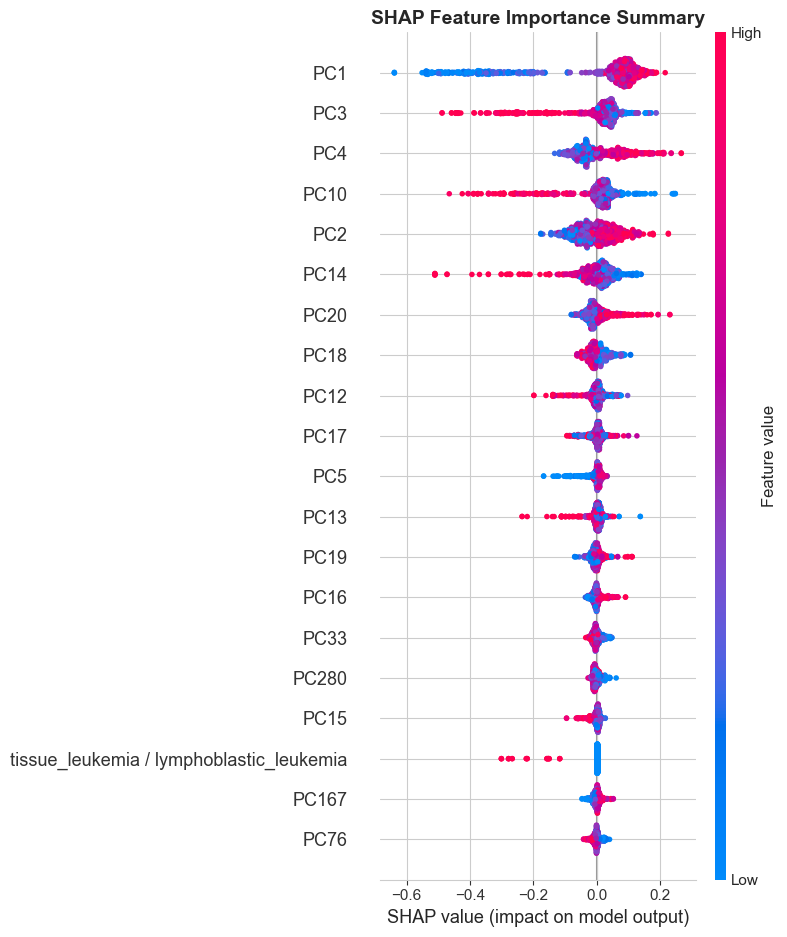


📊 Top 20 Features by SHAP Importance:
                                 feature  shap_importance
                                     PC1         0.148762
                                     PC3         0.063836
                                     PC4         0.054954
                                    PC10         0.051461
                                     PC2         0.047281
                                    PC14         0.040888
                                    PC20         0.024480
                                    PC18         0.019327
                                    PC12         0.015753
                                    PC17         0.013074
                                     PC5         0.012344
                                    PC13         0.012047
                                    PC19         0.011033
                                    PC16         0.008742
                                    PC33         0.008717
                                 

In [12]:
# SHAP value analysis for feature interactions (if SHAP is available)
try:
    import shap
    
    print("Calculating SHAP values (this may take a few minutes)...")
    
    # Sample data for faster computation
    sample_size = min(1000, len(X))
    sample_idx = np.random.choice(len(X), sample_size, replace=False)
    X_sample = X[sample_idx]
    
    # Create explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False, max_display=20)
    plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature importance from SHAP
    shap_importance = np.abs(shap_values).mean(axis=0)
    df_shap = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance
    }).sort_values('shap_importance', ascending=False)
    
    print("\n📊 Top 20 Features by SHAP Importance:")
    print(df_shap.head(20).to_string(index=False))
    
    # Compare with gain-based importance
    df_compare = df_importance.merge(df_shap, on='feature', how='left')
    correlation = df_compare[['importance_gain', 'shap_importance']].corr().iloc[0, 1]
    print(f"\n💡 Correlation between gain-based and SHAP importance: {correlation:.3f}")
    
except ImportError:
    print("⚠️ SHAP not installed. Skipping interaction analysis.")
    print("   Install with: pip install shap")
except Exception as e:
    print(f"⚠️ Could not compute SHAP values: {str(e)}")

## 7. Key Insights Summary

In [14]:
print("=" * 90)
print("KEY INSIGHTS FROM FEATURE IMPORTANCE ANALYSIS")
print("=" * 90)

print("\n🧬 GENE EXPRESSION PATTERNS:")
top_3_pcs = df_pc_importance.nlargest(3, 'importance_gain')
for i, row in top_3_pcs.iterrows():
    print(f"   • {row['feature']}: {row['importance_gain_pct']:.2f}% importance")

print(f"\n   • Top {pcs_80} PCs account for 80% of expression-based predictive power")
print(f"   • Feature sparsity: Only ~{(df_pc_importance['importance_gain'] > 0).sum()} PCs actively used")

if len(tissue_features) > 0:
    print("\n🔬 TISSUE EFFECTS:")
    top_tissues = df_tissue_importance.head(3)
    for i, row in top_tissues.iterrows():
        print(f"   • {row['tissue_clean']}: {row['importance_gain_pct']:.2f}% importance")
    
    print(f"\n   • Tissue features contribute {total_tissue_importance/(total_pc_importance+total_tissue_importance)*100:.1f}% to predictions")
    print(f"   • Expression patterns dominate tissue context")

print("\n💡 MODELING IMPLICATIONS:")
print("   1. Dimensionality reduction is effective (few PCs needed)")
print("   2. Early PCs don't always dominate - check middle-range PCs")
print("   3. Gene expression is primary driver of drug response")
if len(tissue_features) > 0:
    print("   4. Tissue context provides additional signal")
print("   5. Consider feature selection to reduce model complexity")

print("\n📊 RECOMMENDATIONS:")
print("   • Focus on top PCs for model optimization")
print("   • Investigate biological meaning of top PCs")
print("   • Use feature importance for input pruning")
print("   • Consider PC-specific models for different drug classes")

print("\n" + "=" * 90)

KEY INSIGHTS FROM FEATURE IMPORTANCE ANALYSIS

🧬 GENE EXPRESSION PATTERNS:
   • PC1: 8.29% importance
   • PC3: 3.88% importance
   • PC4: 2.32% importance

   • Top 292 PCs account for 80% of expression-based predictive power
   • Feature sparsity: Only ~512 PCs actively used

🔬 TISSUE EFFECTS:
   • leukemia / lymphoblastic_leukemia: 0.34% importance
   • pancreas: 0.13% importance
   • lymphoma / B_cell_lymphoma: 0.13% importance

   • Tissue features contribute 0.7% to predictions
   • Expression patterns dominate tissue context

💡 MODELING IMPLICATIONS:
   1. Dimensionality reduction is effective (few PCs needed)
   2. Early PCs don't always dominate - check middle-range PCs
   3. Gene expression is primary driver of drug response
   4. Tissue context provides additional signal
   5. Consider feature selection to reduce model complexity

📊 RECOMMENDATIONS:
   • Focus on top PCs for model optimization
   • Investigate biological meaning of top PCs
   • Use feature importance for inp

## 8. PC Correlation Heatmap

Visualize relationships between top principal components.

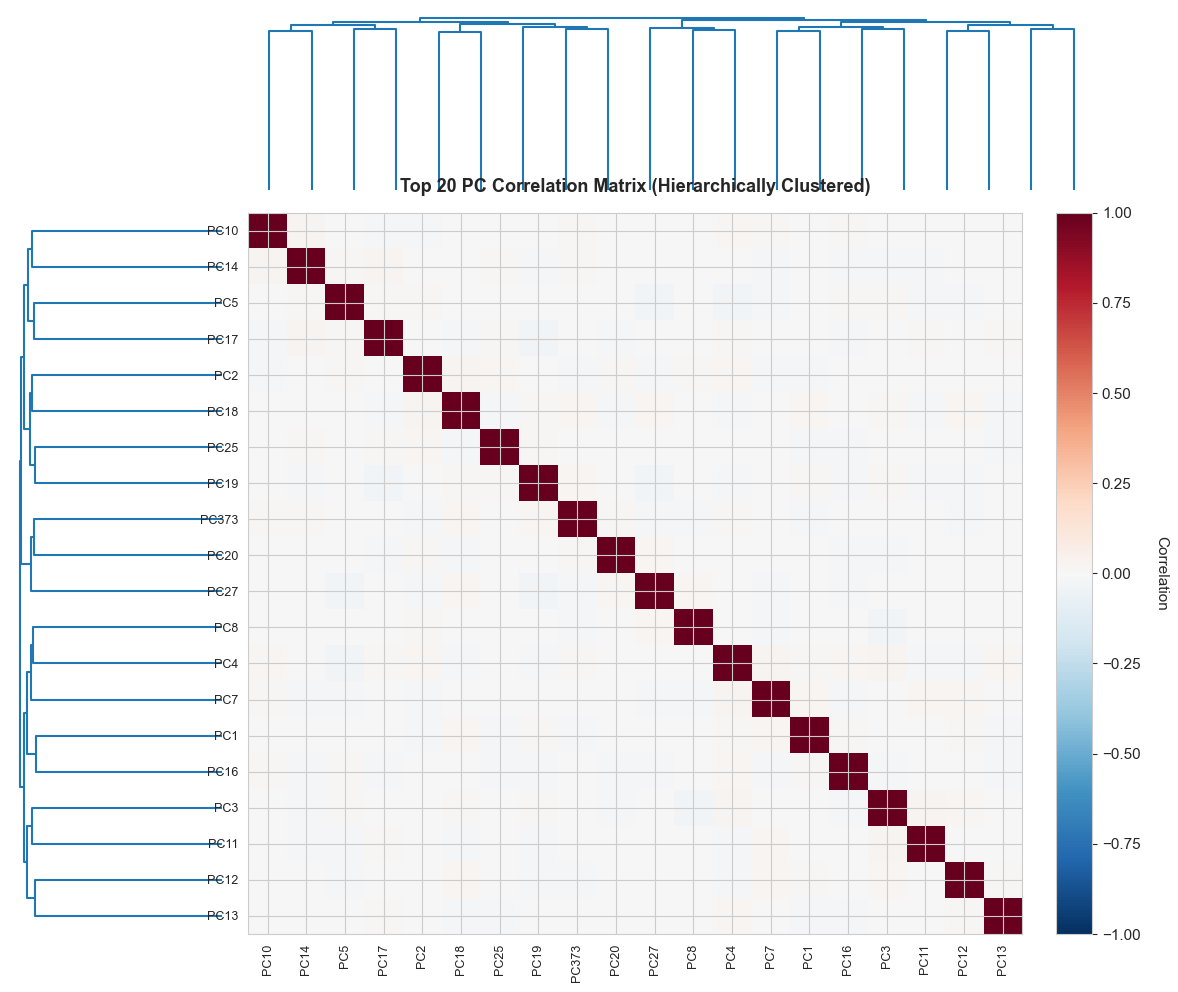


💡 Interpretation:
   • Clustered by similarity to reveal PC groupings
   • Red: Positive correlation, Blue: Negative correlation
   • Blocks indicate groups of related principal components
   • Highest correlation: 0.030


In [17]:
# Select top PCs by importance
top_n_pcs = 20
top_pc_features = df_pc_importance.nlargest(top_n_pcs, 'importance_gain')['feature'].values
top_pc_indices = [int(f.replace('PC', '')) - 1 for f in top_pc_features]

# Get PC data for these features (only PC features, not tissue)
X_pcs = X[:, top_pc_indices]

# Compute correlation matrix
pc_corr_matrix = np.corrcoef(X_pcs.T)

# Create clustered heatmap
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Compute linkage for hierarchical clustering using correlation distance
linkage_matrix = linkage(pdist(X_pcs.T, metric='correlation'), method='ward')

# Create figure
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 4], height_ratios=[1, 4],
                      hspace=0.05, wspace=0.05)

# Top dendrogram
ax_top = fig.add_subplot(gs[0, 1])
dend_top = dendrogram(linkage_matrix, ax=ax_top, no_labels=True, color_threshold=0)
ax_top.axis('off')

# Left dendrogram  
ax_left = fig.add_subplot(gs[1, 0])
dend_left = dendrogram(linkage_matrix, ax=ax_left, no_labels=True, 
                       orientation='left', color_threshold=0)
ax_left.axis('off')

# Reorder correlation matrix according to clustering
order = dend_top['leaves']
pc_corr_reordered = pc_corr_matrix[order, :][:, order]
top_pc_features_reordered = top_pc_features[order]

# Main heatmap
ax_main = fig.add_subplot(gs[1, 1])
im = ax_main.imshow(pc_corr_reordered, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)
cbar.set_label('Correlation', rotation=270, labelpad=20, fontsize=11)

# Set ticks and labels
ax_main.set_xticks(range(top_n_pcs))
ax_main.set_yticks(range(top_n_pcs))
ax_main.set_xticklabels(top_pc_features_reordered, rotation=90, fontsize=9)
ax_main.set_yticklabels(top_pc_features_reordered, fontsize=9)

ax_main.set_title(f'Top {top_n_pcs} PC Correlation Matrix (Hierarchically Clustered)', 
                  fontsize=13, fontweight='bold', pad=15)

plt.show()

print("\n💡 Interpretation:")
print("   • Clustered by similarity to reveal PC groupings")
print("   • Red: Positive correlation, Blue: Negative correlation")
print("   • Blocks indicate groups of related principal components")
print(f"   • Highest correlation: {np.max(pc_corr_reordered[np.triu_indices(top_n_pcs, k=1)]):.3f}")

## 9. Parallel Coordinates Plot

Visualize feature patterns across top principal components.

In [ ]:
# Create parallel coordinates plot for top PCs
from pandas.plotting import parallel_coordinates

# Select subset of samples (for clarity)
n_samples_viz = 500
sample_indices = np.random.choice(len(X), n_samples_viz, replace=False)

# Get top 10 PCs
top_10_pcs = df_pc_importance.nlargest(10, 'importance_gain')['feature'].values
top_10_indices = [int(f.replace('PC', '')) - 1 for f in top_10_pcs]

# Create dataframe (only PC features, not tissue)
df_parallel = pd.DataFrame(
    X[sample_indices][:, top_10_indices],
    columns=top_10_pcs
)

# Add response category
y_subset = y[sample_indices]
df_parallel['Response'] = pd.cut(
    y_subset,
    bins=[-np.inf, -1, 1, np.inf],
    labels=['Sensitive', 'Moderate', 'Resistant']
)

# Normalize features for better visualization
for col in top_10_pcs:
    df_parallel[col] = (df_parallel[col] - df_parallel[col].mean()) / df_parallel[col].std()

# Create plot
fig, ax = plt.subplots(figsize=(16, 6))

# Plot parallel coordinates
parallel_coordinates(
    df_parallel,
    'Response',
    colormap='RdYlGn_r',
    alpha=0.3,
    ax=ax
)

ax.set_title('Parallel Coordinates: Top 10 PCs by Drug Response', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Principal Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Value (Z-score)', fontsize=12, fontweight='bold')
ax.legend(title='Drug Response', loc='upper right', fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Each line represents a sample's feature values across PCs")
print("   • Colors indicate drug response categories")
print("   • Parallel patterns suggest feature interactions")
print("   • Crossings indicate differing feature contributions")

NameError: name 'y_train_subset' is not defined